# Project X -- Vinay Gannamaneni

**TA Help:** (for instance) John Smith, Alice Jones, etc., list names of any TAs who helped you

- For example: Help with figuring out how to write a function (describe the tasks that they helped you with)

**Collaboration:** My Friend in CS, My Uncle, Another Student, etc., list names of any other people who helped you

(describe the tasks that they helped you with)
- For example: helped figuring out how to load the dataset.
- Another example: helped debug error with my plot.

**Internet Resources:** Stack Exchange, Stack Overflow, etc.

(describe any information that you learned from internet resources, including the URLs)
- Used google for deliverable 1.3 to find how date-time data gets stored.

**ChatGPT, Gemini, Claude, etc:** Any language models or generative AI chatbots that helped you.

(if you used any such tools, please tell us here)
- For example:  I asked ChatGPT how to define a new data frames
- Another example:  Gemini told me how to make a function for sorting my data

- ***Link to AI Chat History***: Please share a link to your chat if you used AI (ex. ChatGPT Shared Links)
**OVERALL MESSAGE:** Any time that you used anything except your brain to solve the questions in these projects, you need to disclose such resources at the start of the project, with details about your usage of the tools.

**YOUR OWN WORK:** Even when you utilize other resources, do NOT just copy and paste.  Write all explanations in your own words, using several sentences in English, which are understandable and which you wrote (and did not just copy and paste).

## Question 1

Deliverable 1.1: 
The lubridate package makes it easier to work with dates and times in R. It simplifies converting strings into proper date or datetime objects and helps perform date calculations, comparisons, and formatting in a more readable way.

In [1]:
library(lubridate)
orders <- read.csv("/anvil/projects/tdm/data/restaurant/orders.csv")


Attaching package: 'lubridate'


The following objects are masked from 'package:base':

    date, intersect, setdiff, union




In [2]:
orders$created_at <- as.Date(orders$created_at)

orders$num_day_of_the_week <- wday(orders$created_at)
orders$day_of_the_week <- wday(orders$created_at, label = TRUE)

table(orders$num_day_of_the_week)
table(orders$day_of_the_week)


    1     2     3     4     5     6     7 
18651 19676 22003 20619 22210 15906 16238 


  Sun   Mon   Tue   Wed   Thu   Fri   Sat 
18651 19676 22003 20619 22210 15906 16238 

Created weekday columns and showed the tables

In [3]:
table(orders$num_day_of_the_week, orders$day_of_the_week)

   
      Sun   Mon   Tue   Wed   Thu   Fri   Sat
  1 18651     0     0     0     0     0     0
  2     0 19676     0     0     0     0     0
  3     0     0 22003     0     0     0     0
  4     0     0     0 20619     0     0     0
  5     0     0     0     0 22210     0     0
  6     0     0     0     0     0 15906     0
  7     0     0     0     0     0     0 16238

Create a comparsion table

Date data is stored as class Date, while date-time data is stored as class POSIXct or POSIXlt in R.

## Question 2

In [2]:
library(lubridate)
orders <- read.csv("/anvil/projects/tdm/data/restaurant/orders.csv")


Attaching package: 'lubridate'


The following objects are masked from 'package:base':

    date, intersect, setdiff, union




In [3]:
orders$created_at <- as.Date(orders$created_at)

orders$month <- month(orders$created_at, label = TRUE)
orders$year  <- year(orders$created_at)

Convert "created_at" to "Date" and create month and year columns

In [5]:
range(orders$created_at[!is.na(orders$item_count)])

[1] "2019-06-01" "2020-02-29"

Check the time span of orders that actually had items

The actual time span of orders with items is approximately from June 2019 to February 2020. This means only those months had recorded item orders.

In [17]:
item_month <- tapply(orders$item_count, orders$month, sum, na.rm = TRUE)
item_month

Jan   Feb   Mar   Apr   May   Jun   Jul   Aug   Sep   Oct   Nov   Dec 
40410 51197    NA    NA     0 27839 27296 23853 16098 31527 43102 47479

- March and April show NA values because no orders were placed during those months, meaning there are no created_at entries that fall in March or April.
- When the month() function is applied, it returns NA for missing date values.
- May does not show NA because it has some valid created_at entries, even if the number of items ordered is zero — so it still appears as a valid month value.

In [19]:
item_year_month <- tapply(orders$item_count,
                          list(orders$year, orders$month),
                          sum, na.rm = TRUE)
item_year_month

,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
2019,NA,NA,NA,NA,0,27839,27296,23853,16098,31527,43102,47479
2020,40410,51197,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA


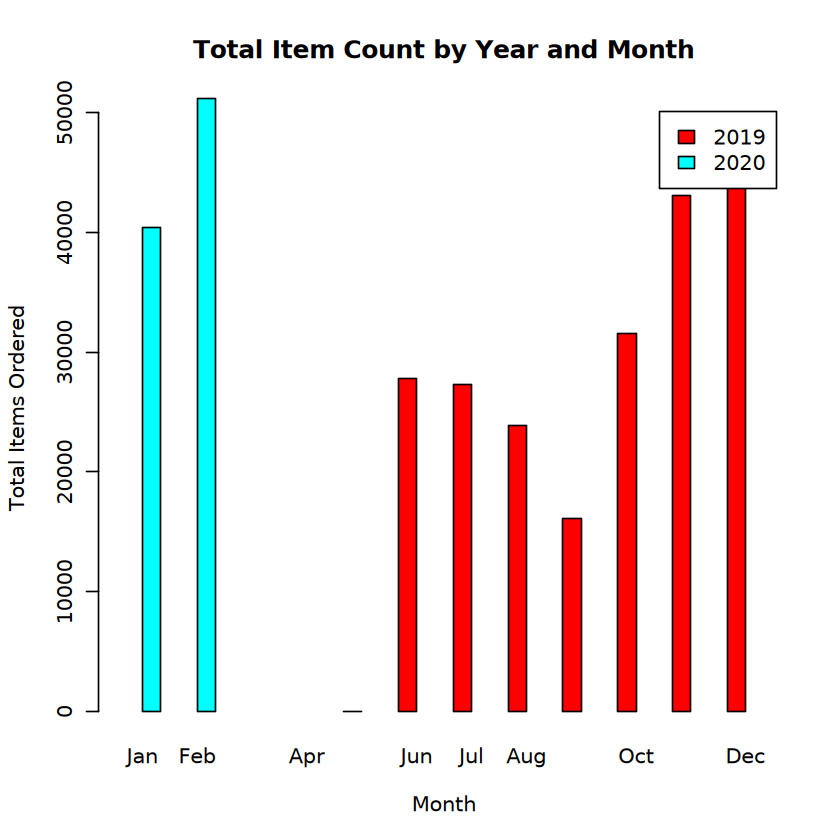

In [20]:
barplot(item_year_month,
        beside = TRUE,
        legend = TRUE,
        main = "Total Item Count by Year and Month",
        xlab = "Month",
        ylab = "Total Items Ordered",
        col = rainbow(nrow(item_year_month)))

## Question 3

In [10]:
library(lubridate)
flights <- read.csv("/anvil/projects/tdm/data/flights/subset/1997.csv")

In [11]:
flights$full_dates <- ymd(paste(flights$Year, flights$Month, flights$DayofMonth, sep="-"))
flights$DepTime[flights$DepTime == 2400] <- 0

Create a full_dates column combining Year, Month, DayofMonth and replace 2400 in DepTime with 0

In [12]:
flights$depHour <- floor(flights$DepTime / 100)
flights$depMinute <- round((flights$DepTime / 100 - flights$depHour) * 100)

In [13]:
flights$date_times <- make_datetime(flights$Year, flights$Month, flights$DayofMonth, flights$depHour, flights$depMinute)

Create date_times column including date and time

In [14]:
head(flights$depHour)
head(flights$depMinute)

[1] 16 16 16 16 15 10

[1] 15 24 26 28  3 29

- ymd stands for Year-Month-Day
- The ymd() function converts year, month, and day information into a proper Date object
- Example:
ymd("1997-03-15")
- Output: "1997-03-15" as a Date object

## Question 4

In [15]:
bostonDF  <- subset(flights, Origin == "BOS")
phoenixDF <- subset(flights, Origin == "PHX")
chicagoDF <- subset(flights, Origin == "MDW")
seattleDF <- subset(flights, Origin == "SEA")

Create dataframes for each origin

In [16]:
boston_distance  <- tapply(bostonDF$Distance, bostonDF$Month, mean, na.rm = TRUE)
phoenix_distance <- tapply(phoenixDF$Distance, phoenixDF$Month, mean, na.rm = TRUE)
chicago_distance <- tapply(chicagoDF$Distance, chicagoDF$Month, mean, na.rm = TRUE)
seattle_distance <- tapply(seattleDF$Distance, seattleDF$Month, mean, na.rm = TRUE)

In [17]:
boston_distance["10"]
phoenix_distance["10"]
chicago_distance["10"]
seattle_distance["10"]

10 
881.4267

10 
764.5401

10 
363.4114

10 
1092.401

Average flight distance per month using tapply() and compare average distances in October

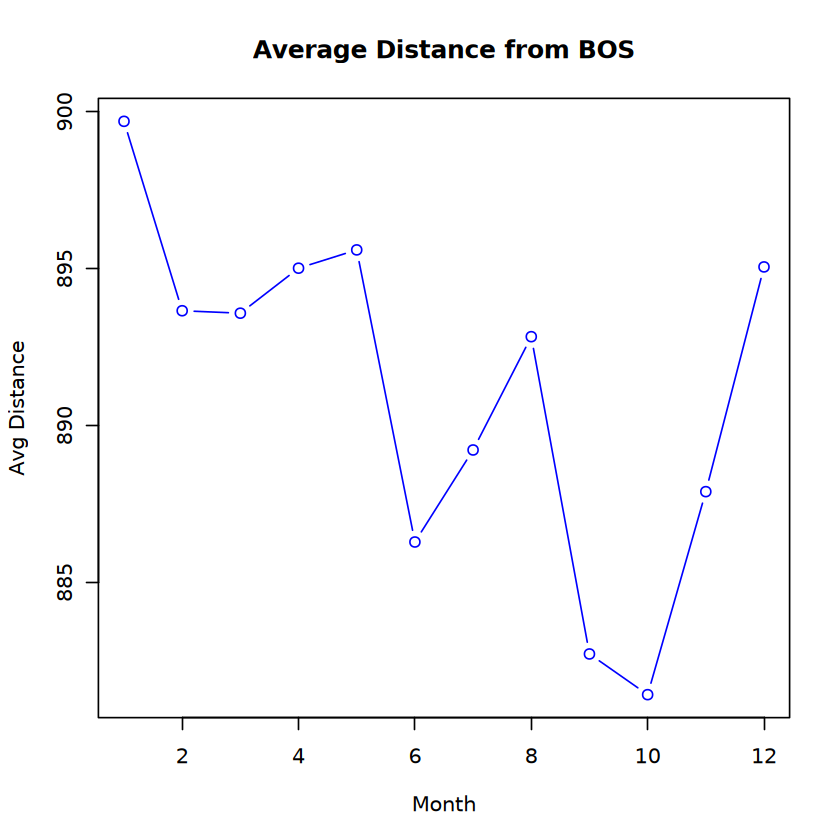

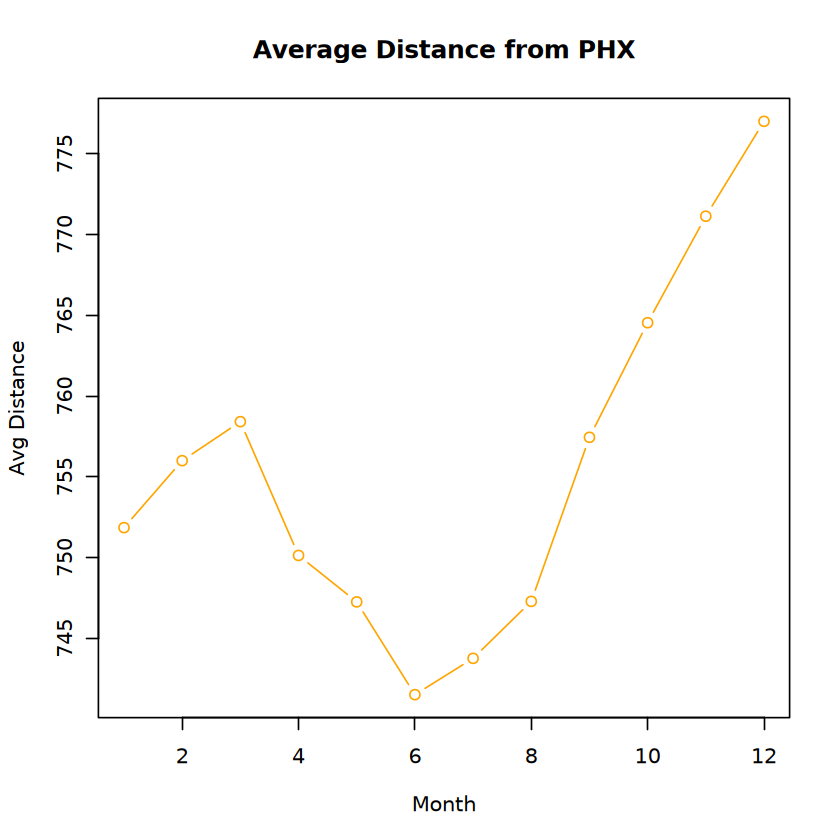

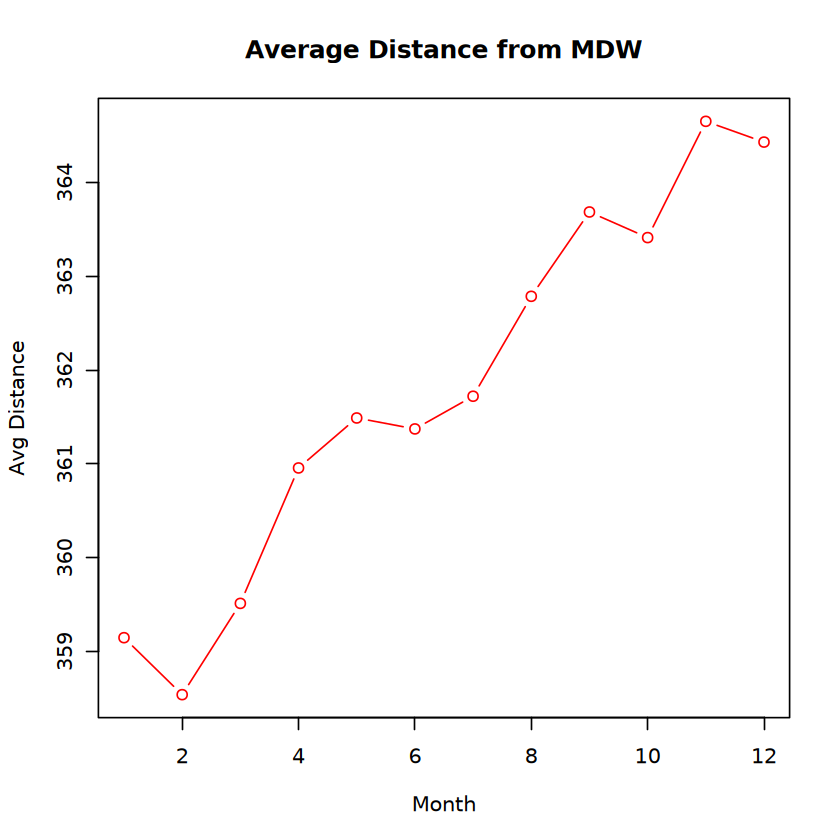

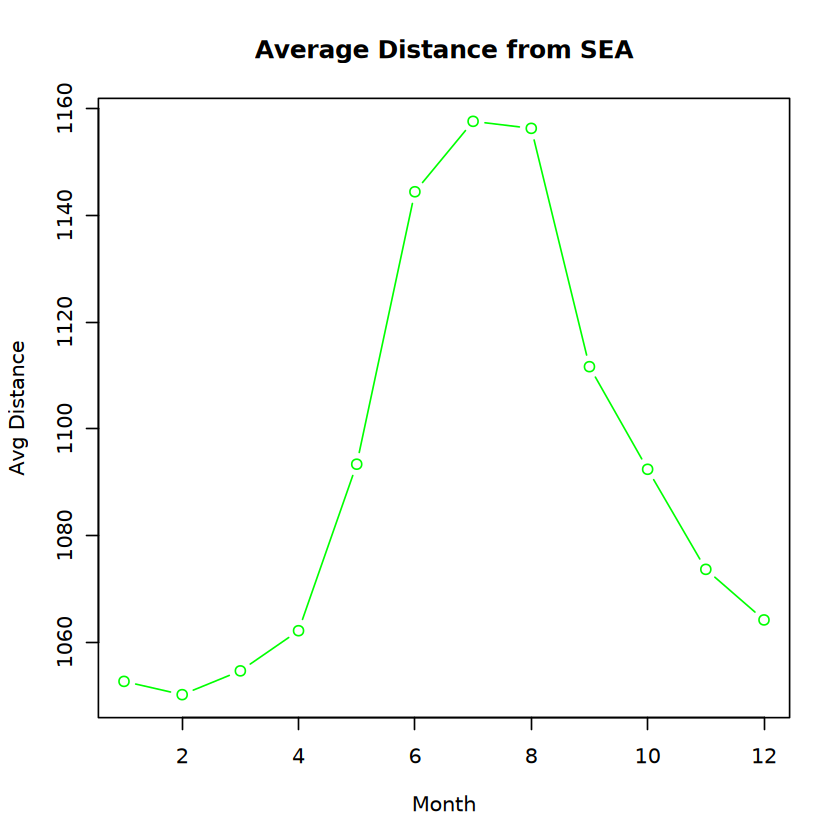

In [21]:
# Boston
plot(boston_distance, type='b', col='blue', main='Average Distance from BOS', xlab='Month', ylab='Avg Distance')

# Phoenix
plot(phoenix_distance, type='b', col='orange', main='Average Distance from PHX', xlab='Month', ylab='Avg Distance')

# Chicago
plot(chicago_distance, type='b', col='red', main='Average Distance from MDW', xlab='Month', ylab='Avg Distance')

# Seattle
plot(seattle_distance, type='b', col='green', main='Average Distance from SEA', xlab='Month', ylab='Avg Distance')

Individual line plots for each origin

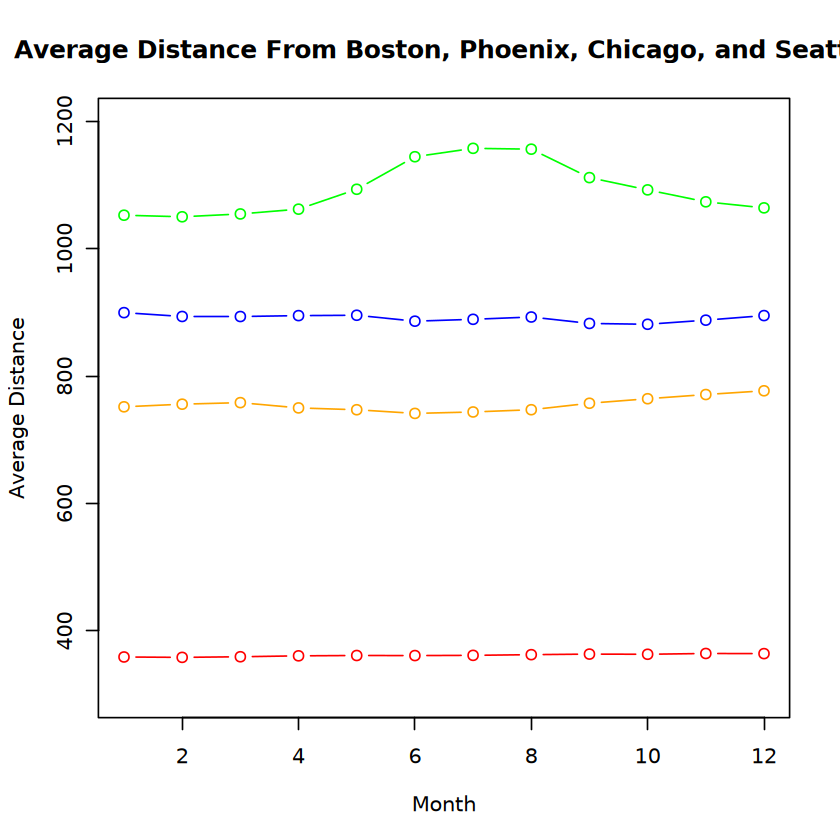

In [22]:
plot(boston_distance,
     type='b',
     col='blue',
     ylim=c(300, 1200),
     main='Average Distance From Boston, Phoenix, Chicago, and Seattle',
     xlab='Month',
     ylab='Average Distance'
)

lines(phoenix_distance, type='b', col='orange')
lines(chicago_distance, type='b', col='red')
lines(seattle_distance, type='b', col='green')

Combined plot for all 4 origins

1. Boston (BOS) → flights mostly within Eastern US → shorter average distances
2. Phoenix (PHX) → flights across US including West Coast → higher average distances
3. Chicago (MDW) → mostly Midwest/East Coast → moderate distances
4. Seattle (SEA) → flights across West Coast + cross-country → higher distances

- Observation: Coast airports (PHX, SEA) tend to have longer average flights than central/east airports (MDW, BOS)


## Question 5

In [23]:
boston_total_distance  <- tapply(bostonDF$Distance,  bostonDF$Month,  sum, na.rm = TRUE)
phoenix_total_distance <- tapply(phoenixDF$Distance, phoenixDF$Month, sum, na.rm = TRUE)
chicago_total_distance <- tapply(chicagoDF$Distance, chicagoDF$Month, sum, na.rm = TRUE)
seattle_total_distance <- tapply(seattleDF$Distance, seattleDF$Month, sum, na.rm = TRUE)

Total flight distance per month using tapply() and display totals for verification

In [24]:
boston_total_distance
phoenix_total_distance
chicago_total_distance
seattle_total_distance

1       2       3       4       5       6       7       8       9      10 
7441412 6587186 7418539 7323044 7413792 7325204 7602872 7592676 7245397 7505348 
     11      12 
6970880 7134517

1        2        3        4        5        6        7        8 
10562012  9713066 10882496 10359314 10551242 10076382 10435682 10443325 
       9       10       11       12 
10414872 11000203 10649386 11112787

1       2       3       4       5       6       7       8       9      10 
1332798 1199319 1315460 1290059 1336787 1333826 1379242 1379674 1355815 1402768 
     11      12 
1304719 1350939

1        2        3        4        5        6        7        8 
 8046435  7278639  8175388  8108407  8923976  9941597 10996256 11072807 
       9       10       11       12 
 9251033  8940213  8009410  8302618

In [25]:
all_totals <- c(boston_total_distance,
                phoenix_total_distance,
                chicago_total_distance,
                seattle_total_distance)

max_distance <- max(all_totals, na.rm = TRUE)
min_distance <- min(all_totals, na.rm = TRUE)

Combine all total distances into one vector to find minimum and maximum values

In [26]:
max_distance
min_distance

[1] 11112787

[1] 1199319

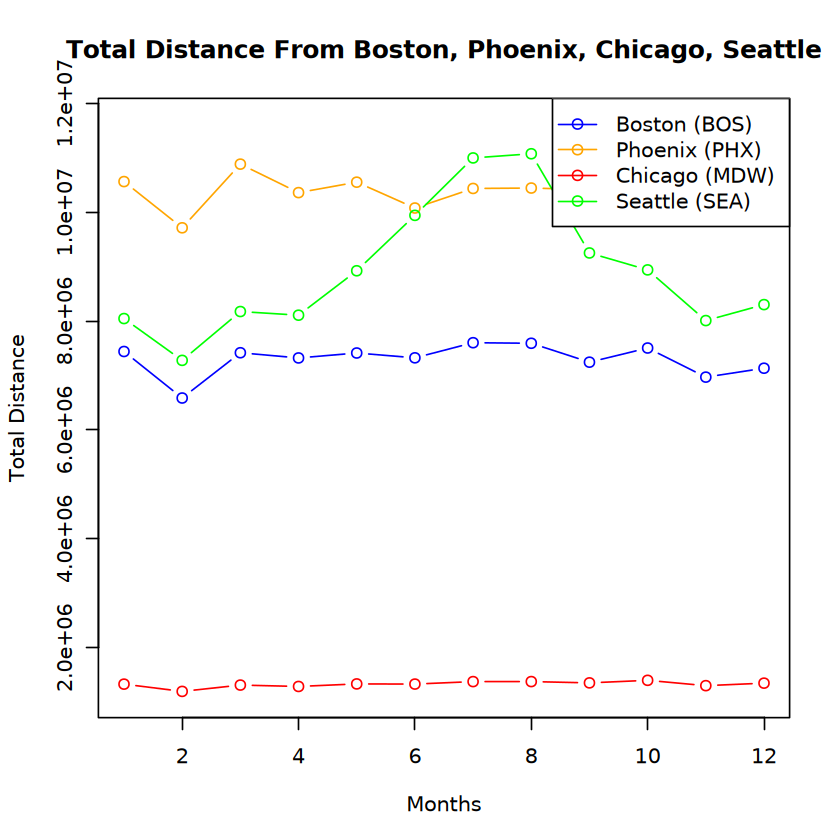

In [32]:
plot(boston_total_distance,
     type='b',
     col='blue',
     ylim=c(min_distance * 0.95, max_distance * 1.05),  # small buffer for readability
     main='Total Distance From Boston, Phoenix, Chicago, Seattle',
     xlab='Months',
     ylab='Total Distance'
)

lines(phoenix_total_distance, type='b', col='orange')
lines(chicago_total_distance, type='b', col='red')
lines(seattle_total_distance, type='b', col='green')

legend("topright",
       legend=c("Boston (BOS)", "Phoenix (PHX)", "Chicago (MDW)", "Seattle (SEA)"),
       col=c("blue", "orange", "red", "green"),
       lty=1, pch=1)

A line plot showing the total distance by month and location

## Pledge

By submitting this work I hereby pledge that this is my own, personal work. I've acknowledged in the designated place at the top of this file all sources that I used to complete said work, including but not limited to: online resources, books, and electronic communications. I've noted all collaboration with fellow students and/or TA's. I did not copy or plagiarize another's work.

> As a Boilermaker pursuing academic excellence, I pledge to be honest and true in all that I do. Accountable together – We are Purdue.

https://www.purdue.edu/odos/osrr/honor-pledge/
